In [54]:
from src.utils.config import DATASET_FINAL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
sns.set_theme(style="whitegrid")
sns.set_palette("pastel")

plt.rcParams["figure.figsize"] = (12,6)

In [56]:
data = pd.read_csv(DATASET_FINAL)

In [57]:
print("Total audios:", len(data))

Total audios: 60289


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60289 entries, 0 to 60288
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   audio              60289 non-null  object 
 1   label              60289 non-null  object 
 2   labels             51197 non-null  object 
 3   human_label        60289 non-null  object 
 4   human_labels       51197 non-null  object 
 5   path               60289 non-null  object 
 6   dataset_source     60289 non-null  object 
 7   split              60289 non-null  object 
 8   env                54744 non-null  object 
 9   emergency          54744 non-null  object 
 10  file_exists        60289 non-null  bool   
 11  audio_format       60289 non-null  object 
 12  duration           60289 non-null  float64
 13  sample_rate        60289 non-null  int64  
 14  channels           60289 non-null  object 
 15  bit_depth          60280 non-null  float64
 16  bit_velocity       602

In [5]:
data.isnull().sum().sort_values(ascending=False)

labels               9092
human_labels         9092
emergency            5545
env                  5545
bit_velocity            9
bit_depth               9
audio_format            0
size                    0
channels                0
sample_rate             0
duration                0
audio                   0
file_exists             0
label                   0
split                   0
dataset_source          0
path                    0
human_label             0
date_modification       0
dtype: int64

In [6]:
data.duplicated(subset=["audio"]).sum()

0

In [7]:
data.describe(include="all")

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
count,60289,60289,51197,60289,51197,60289,60289,60289,54744,54744,60289,60289,60289.000000,60289.000000,60289,60280.000000,6.028000e+04,60289.000000,60289
unique,60289,206,3255,60,1680,60289,3,2,3,2,1,1,NaN,NaN,2,NaN,NaN,NaN,575
top,1-115545-A-48.wav,/m/085jw,"[""/m/085jw"", ""/m/04szw"", ""/m/04rlf""]",guitar,"[""percussion"", ""Musical_instrument"", ""music""]",ESC50/1-115545-A-48.wav,zenodo,train,indefinida,False,True,wav,NaN,NaN,Mono,NaN,NaN,NaN,2020-06-16 00:54:28
freq,1,2627,2612,4452,3053,1,51197,48240,26099,51250,60289,60289,NaN,NaN,52296,NaN,NaN,NaN,837
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.036624,44731.046178,NaN,16.404512,8.643400e+05,675.967378,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.357719,6021.038357,NaN,1.876884,5.353738e+05,650.907194,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050000,8000.000000,NaN,8.000000,8.820000e+04,5.980000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.110000,44100.000000,NaN,16.000000,7.056000e+05,189.080000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,44100.000000,NaN,16.000000,7.056000e+05,505.400000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.108000,44100.000000,NaN,16.000000,7.056000e+05,924.110000,NaN


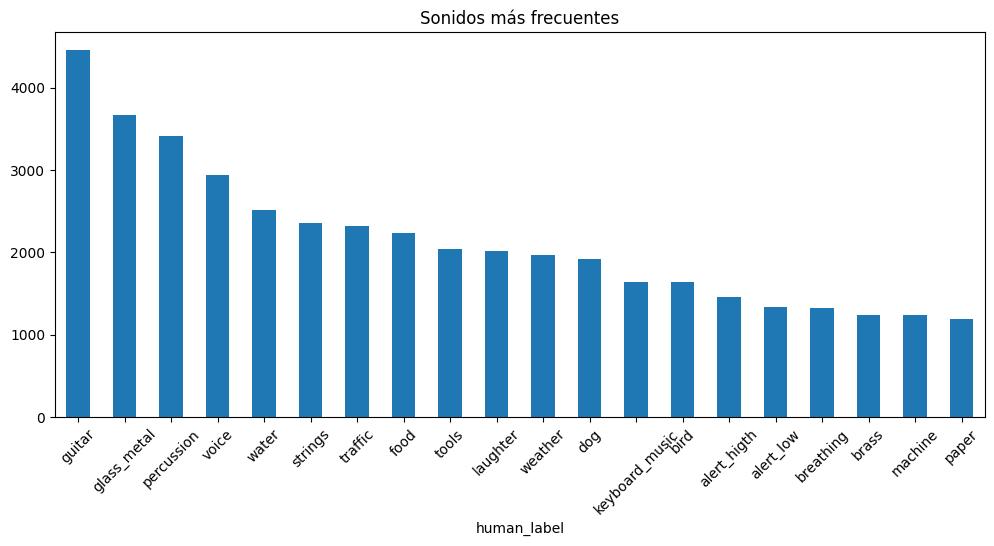

In [8]:
plt.figure(figsize=(12,5))
data["human_label"].value_counts().head(20).plot(kind="bar")
plt.title("Sonidos más frecuentes")
plt.xticks(rotation=45)
plt.show()

In [9]:
data["emergency"].value_counts()

emergency
False    51250
True      3494
Name: count, dtype: int64

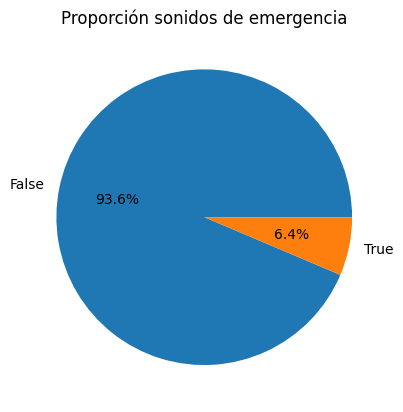

In [10]:
data["emergency"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Proporción sonidos de emergencia")
plt.ylabel("")
plt.show()

In [11]:
for col in data.columns:
    print(col)

audio
label
labels
human_label
human_labels
path
dataset_source
split
env
emergency
file_exists
audio_format
duration
sample_rate
channels
bit_depth
bit_velocity
size
date_modification


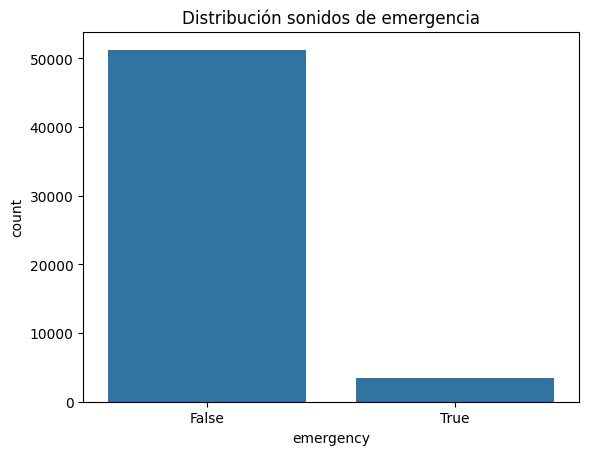

In [12]:
sns.countplot(data=data, x="emergency")
plt.title("Distribución sonidos de emergencia")
plt.show()

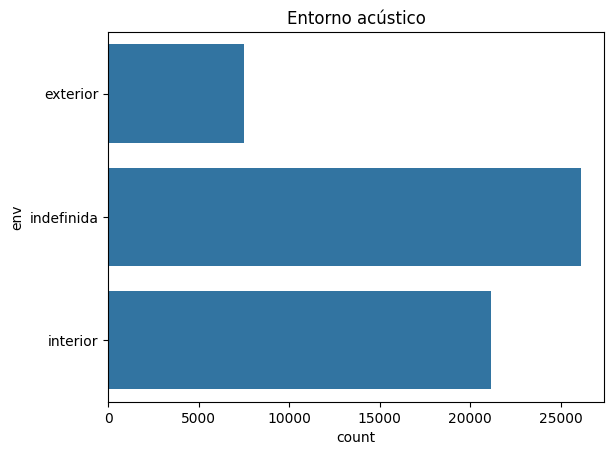

In [13]:
sns.countplot(data=data, y="env")
plt.title("Entorno acústico")
plt.show()

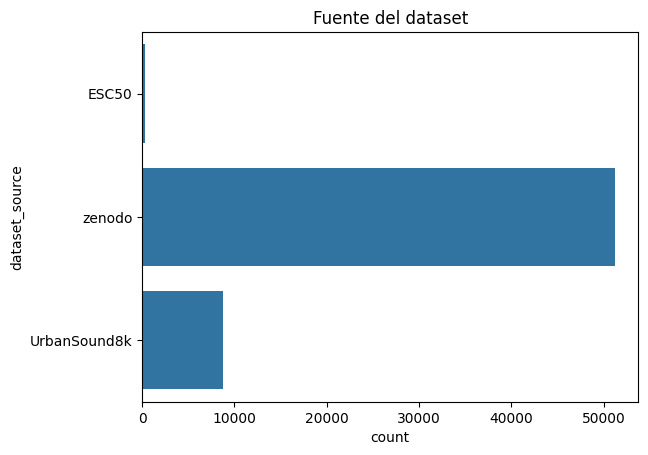

In [14]:
sns.countplot(data=data, y="dataset_source")
plt.title("Fuente del dataset")
plt.show()

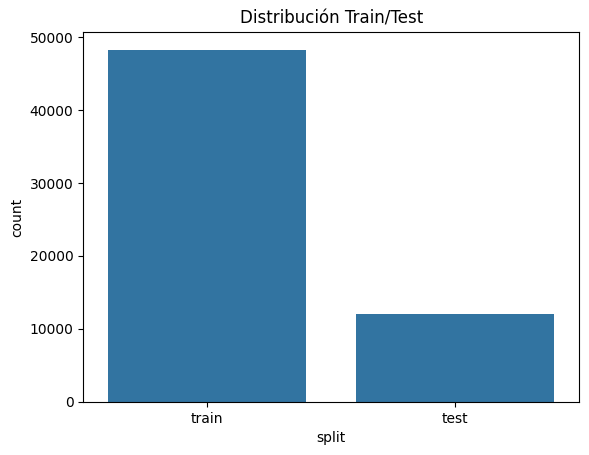

In [15]:
sns.countplot(data=data, x="split")
plt.title("Distribución Train/Test")
plt.show()

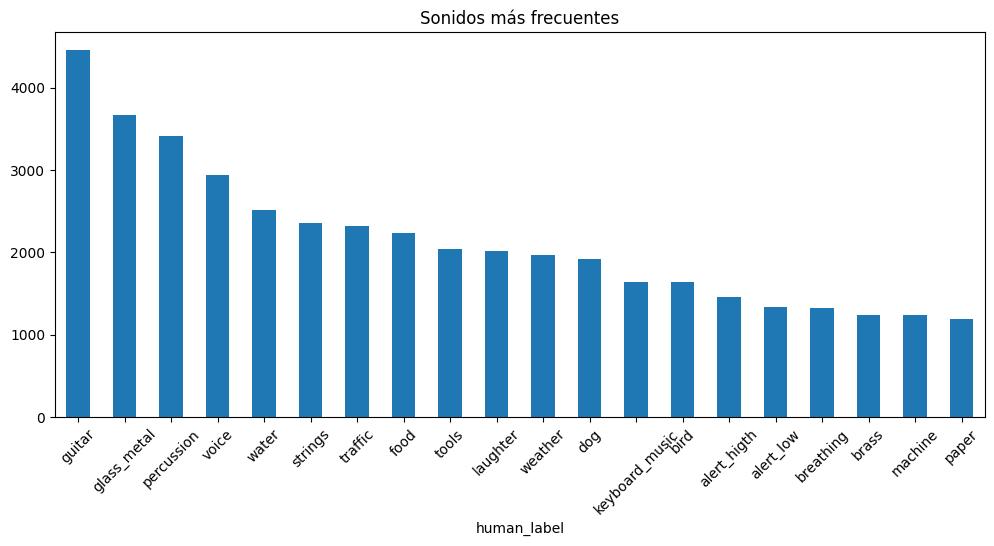

In [16]:
plt.figure(figsize=(12,5))

data["human_label"].value_counts().head(20).plot(kind="bar")

plt.title("Sonidos más frecuentes")
plt.xticks(rotation=45)
plt.show()

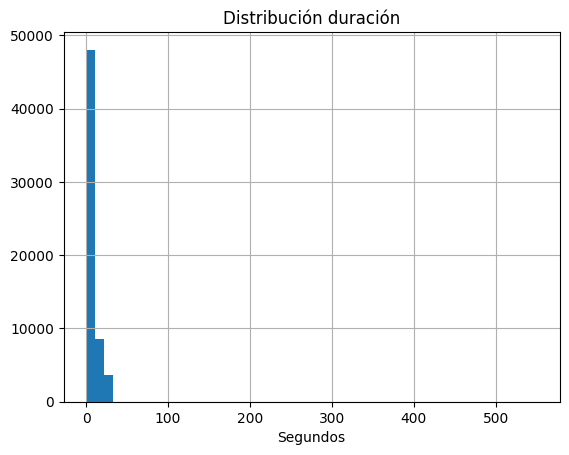

In [17]:
data["duration"].hist(bins=50)

plt.title("Distribución duración")
plt.xlabel("Segundos")
plt.show()

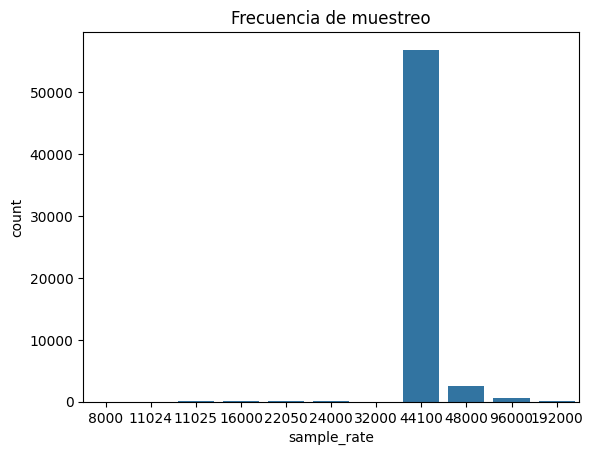

In [18]:
sns.countplot(data=data, x="sample_rate")
plt.title("Frecuencia de muestreo")
plt.show()

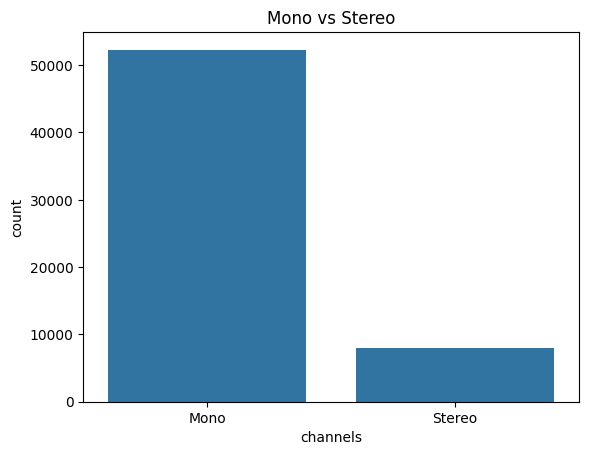

In [19]:
sns.countplot(data=data, x="channels")
plt.title("Mono vs Stereo")
plt.show()

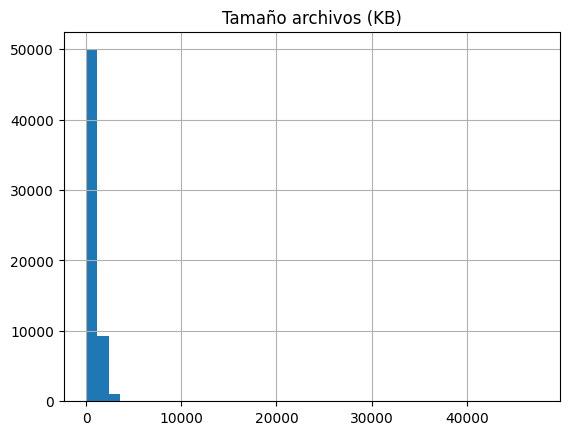

In [20]:
data["size"].hist(bins=40)

plt.title("Tamaño archivos (KB)")
plt.show()

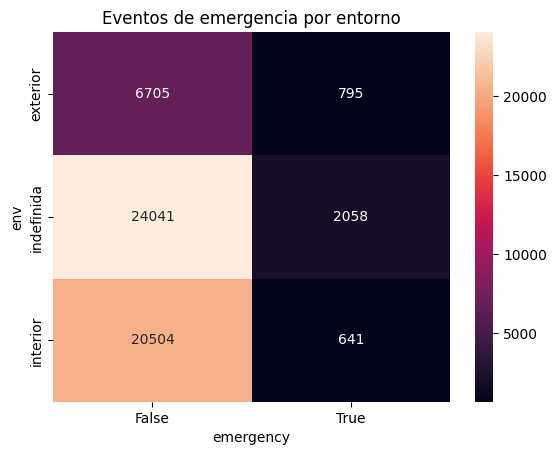

In [21]:
tabla = pd.crosstab(data["env"], data["emergency"])

sns.heatmap(tabla, annot=True, fmt="d")
plt.title("Eventos de emergencia por entorno")
plt.show()

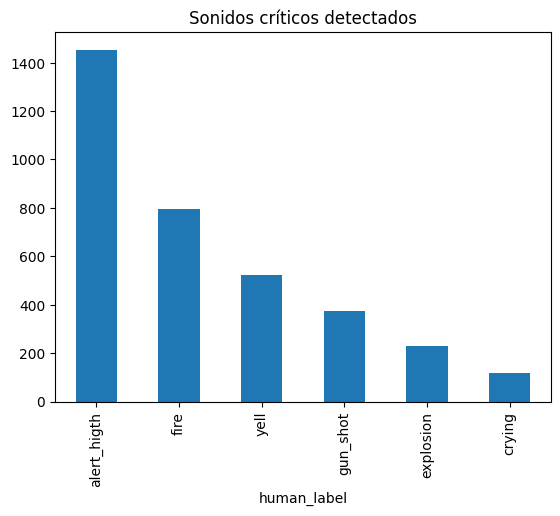

In [22]:
data[data["emergency"] == True]["human_label"] \
    .value_counts() \
    .head(15) \
    .plot(kind="bar")

plt.title("Sonidos críticos detectados")
plt.show()

In [23]:
data["human_label"].value_counts().describe()

count      60.000000
mean     1004.816667
std       994.047922
min        28.000000
25%       242.000000
50%       650.500000
75%      1364.750000
max      4452.000000
Name: count, dtype: float64

## Nuevo análisis base target == LABEL

In [29]:
eda = data.copy()

In [30]:
eda["emergency"] = (
    eda["emergency"]
    .fillna(False)
    .astype(int)
)

C:\Users\nata1\AppData\Local\Temp\ipykernel_15084\3106987934.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


- Se preserva reproducibilidad.
- El dataset original permanece intacto.
- El EDA trabaja sobre una copia controlada.

In [35]:
eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60289 entries, 0 to 60288
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   audio              60289 non-null  object 
 1   label              60289 non-null  object 
 2   labels             51197 non-null  object 
 3   human_label        60289 non-null  object 
 4   human_labels       51197 non-null  object 
 5   path               60289 non-null  object 
 6   dataset_source     60289 non-null  object 
 7   split              60289 non-null  object 
 8   env                54744 non-null  object 
 9   emergency          60289 non-null  int32  
 10  file_exists        60289 non-null  bool   
 11  audio_format       60289 non-null  object 
 12  duration           60289 non-null  float64
 13  sample_rate        60289 non-null  int64  
 14  channels           60289 non-null  object 
 15  bit_depth          60280 non-null  float64
 16  bit_velocity       602

In [36]:
eda.describe(include="all")

,audio,label,labels,human_label,human_labels,path,dataset_source,split,env,emergency,file_exists,audio_format,duration,sample_rate,channels,bit_depth,bit_velocity,size,date_modification
count,60289,60289,51197,60289,51197,60289,60289,60289,54744,60289.000000,60289,60289,60289.000000,60289.000000,60289,60280.000000,6.028000e+04,60289.000000,60289
unique,60289,206,3255,60,1680,60289,3,2,3,NaN,1,1,NaN,NaN,2,NaN,NaN,NaN,575
top,1-115545-A-48.wav,/m/085jw,"[""/m/085jw"", ""/m/04szw"", ""/m/04rlf""]",guitar,"[""percussion"", ""Musical_instrument"", ""music""]",ESC50/1-115545-A-48.wav,zenodo,train,indefinida,NaN,True,wav,NaN,NaN,Mono,NaN,NaN,NaN,2020-06-16 00:54:28
freq,1,2627,2612,4452,3053,1,51197,48240,26099,NaN,60289,60289,NaN,NaN,52296,NaN,NaN,NaN,837
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.057954,NaN,NaN,7.036624,44731.046178,NaN,16.404512,8.643400e+05,675.967378,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.233659,NaN,NaN,7.357719,6021.038357,NaN,1.876884,5.353738e+05,650.907194,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.050000,8000.000000,NaN,8.000000,8.820000e+04,5.980000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,2.110000,44100.000000,NaN,16.000000,7.056000e+05,189.080000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,4.000000,44100.000000,NaN,16.000000,7.056000e+05,505.400000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,9.108000,44100.000000,NaN,16.000000,7.056000e+05,924.110000,NaN


In [37]:
eda.isna().sum().sort_values(ascending=False)

labels               9092
human_labels         9092
env                  5545
bit_velocity            9
bit_depth               9
audio                   0
audio_format            0
size                    0
channels                0
sample_rate             0
duration                0
emergency               0
file_exists             0
label                   0
split                   0
dataset_source          0
path                    0
human_label             0
date_modification       0
dtype: int64

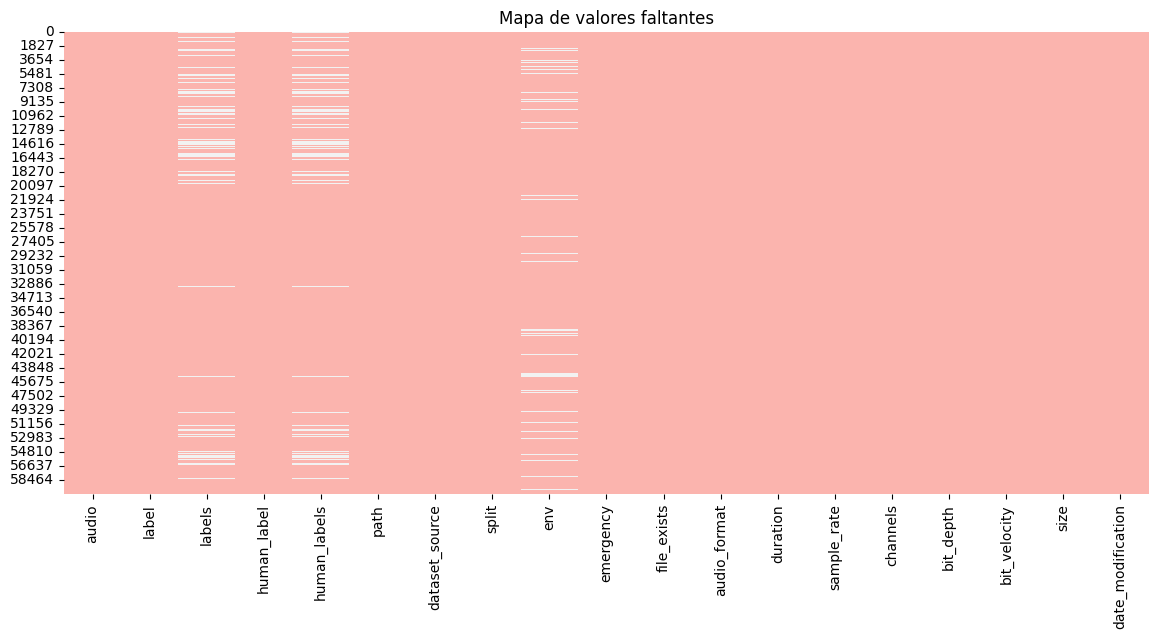

In [38]:
plt.figure(figsize=(14,6))
sns.heatmap(eda.isnull(), cbar=False, cmap="Pastel1")
plt.title("Mapa de valores faltantes")
plt.show()

- Algunas variables presentan valores nulos esperados.
- emergency requería normalización.
- No existen pérdidas críticas de información.

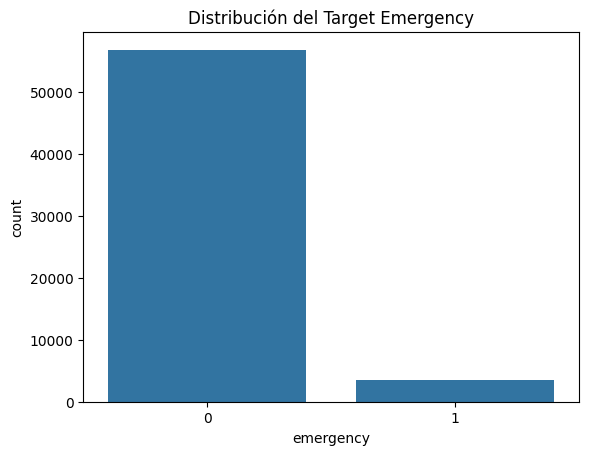

In [39]:
sns.countplot(data=eda, x="emergency")
plt.title("Distribución del Target Emergency")
plt.show()

Se prsenta un deshalanceo evidnete debido a los pocos sonidos que representan emergencias reales.
Situación coherente con escenarios del mundo real.

Por ello el análisis se traslada a nivel de clase sonora (human_label).

In [40]:
emergency_by_sound = (
    eda.groupby("human_label")["emergency"]
    .mean()
    .sort_values(ascending=False)
)

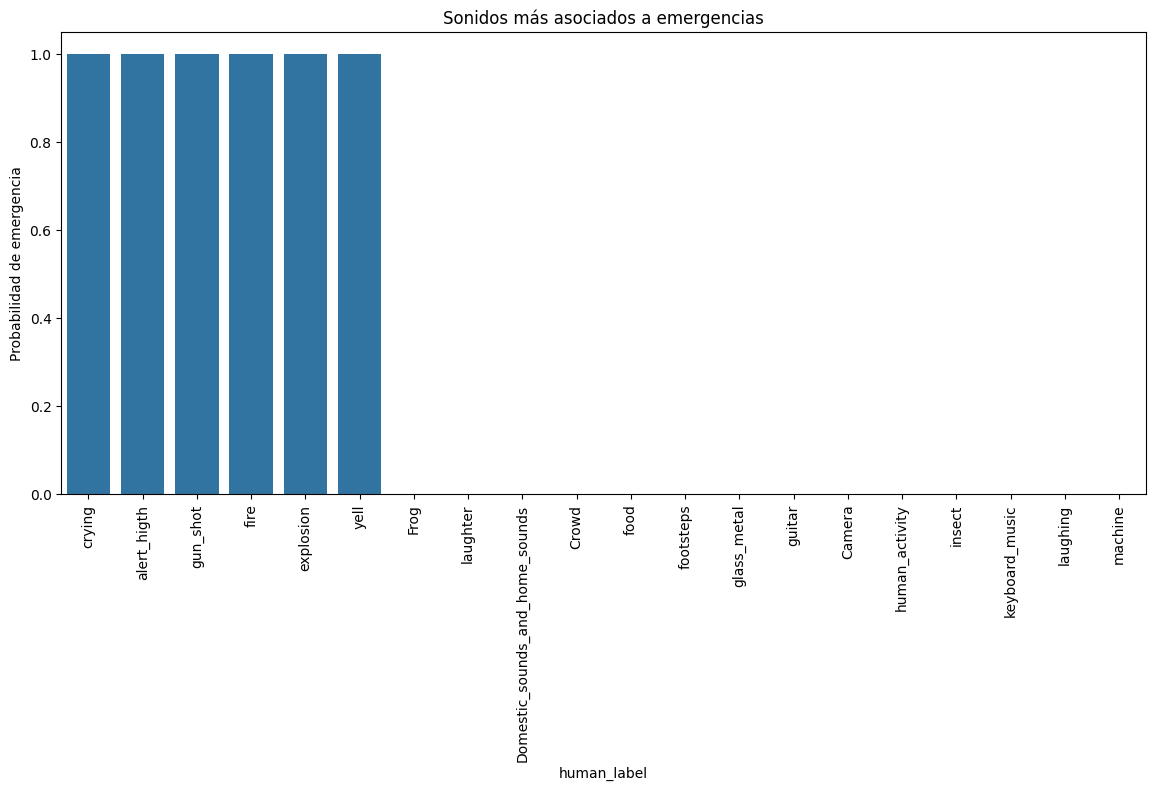

In [41]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=emergency_by_sound.index[:20],
    y=emergency_by_sound.values[:20]
)

plt.xticks(rotation=90)
plt.title("Sonidos más asociados a emergencias")
plt.ylabel("Probabilidad de emergencia")

plt.show()

Se identifican sonidos críticos:

- sirenas
- disparos
- alarmas
- bocinas

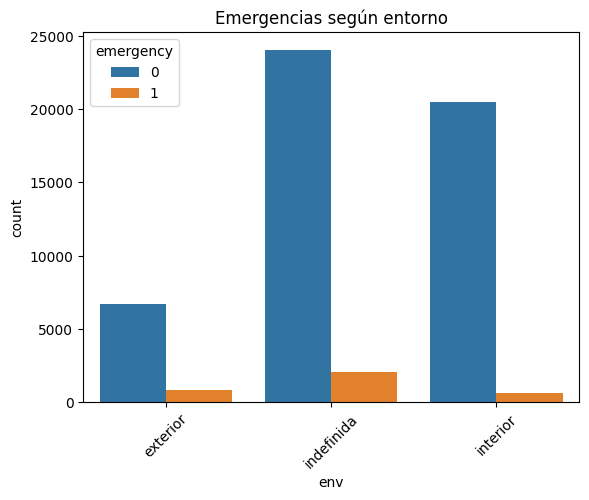

In [42]:
sns.countplot(data=eda, x="env", hue="emergency")
plt.title("Emergencias según entorno")
plt.xticks(rotation=45)
plt.show()

- Ambientes urbanos concentran eventos peligrosos.
- Interiores presentan menor nivel de riesgo. (Revisar la que es exterior pero no tiene sentido en la vida real)

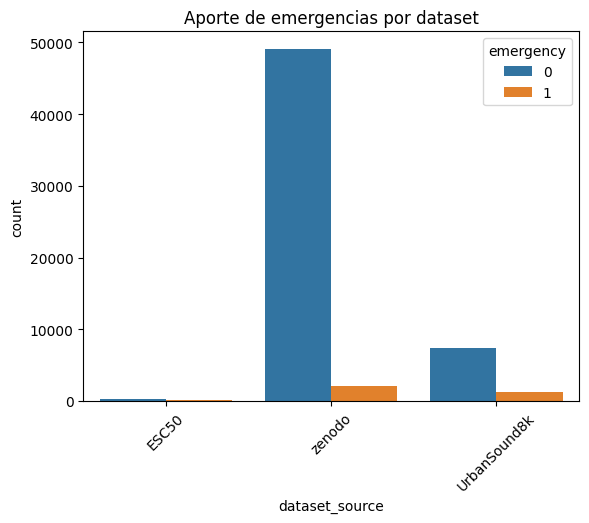

In [43]:
sns.countplot(data=eda, x="dataset_source", hue="emergency")
plt.xticks(rotation=45)
plt.title("Aporte de emergencias por dataset")
plt.show()

- Cada dataset aporta distintos tipos de eventos.
- Reduce sesgo acústico.
- Mejora generalización del modelo.

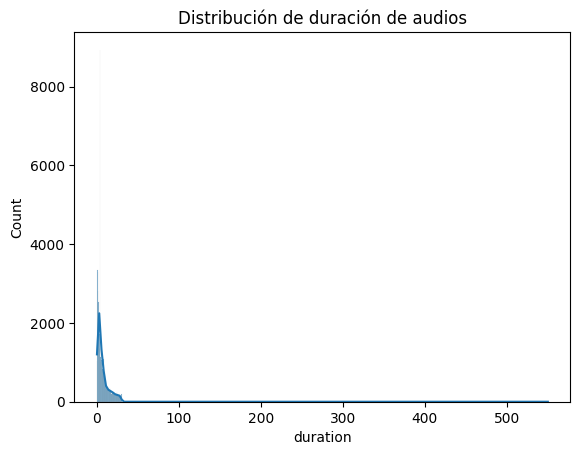

In [44]:
sns.histplot(eda["duration"], kde=True)
plt.title("Distribución de duración de audios")
plt.show()

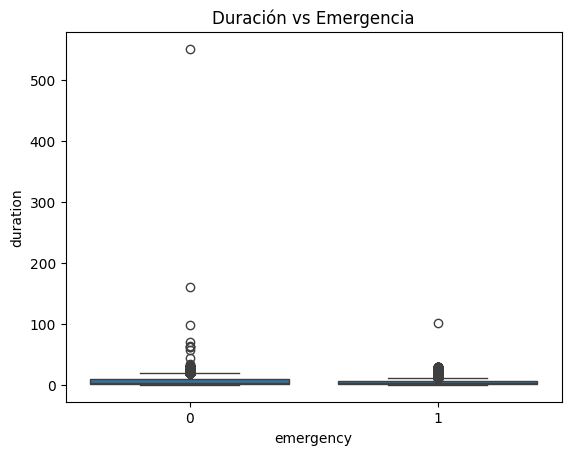

In [45]:
sns.boxplot(data=eda, x="emergency", y="duration")
plt.title("Duración vs Emergencia")
plt.show()

- Sonidos peligrosos suelen ser cortos y abruptos.
- Justifica modelos sensibles a eventos breves.

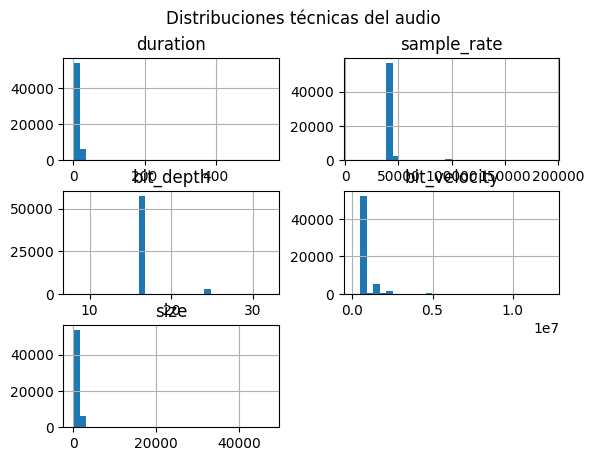

In [46]:
numeric_cols = [
    "duration",
    "sample_rate",
    "channels",
    "bit_depth",
    "bit_velocity",
    "size"
]

eda[numeric_cols].hist(bins=30)
plt.suptitle("Distribuciones técnicas del audio")
plt.show()

- Dataset contiene diversidad técnica.
- Favorece robustez del modelo.
- Reduce sobreajuste a un único formato.

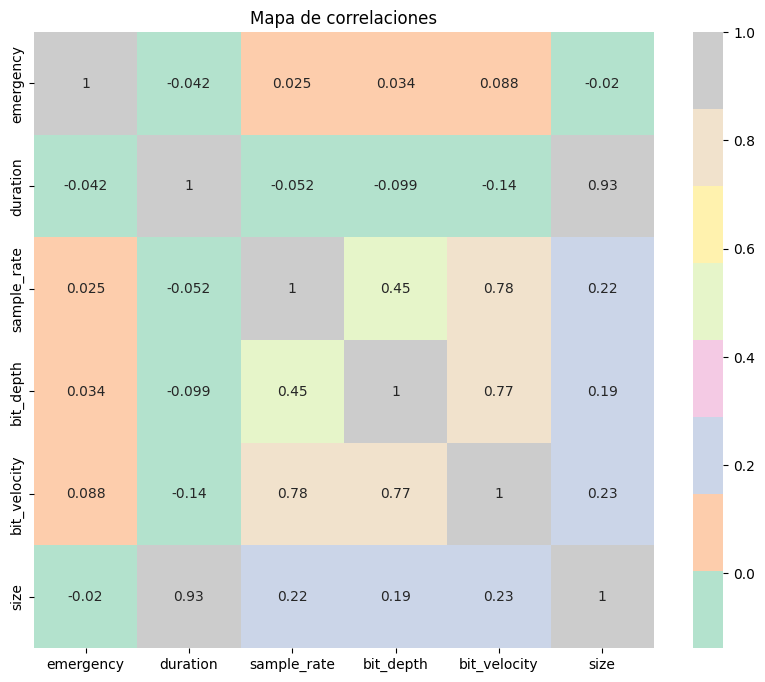

In [48]:
numeric_data = eda.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="Pastel2"
)

plt.title("Mapa de correlaciones")
plt.show()

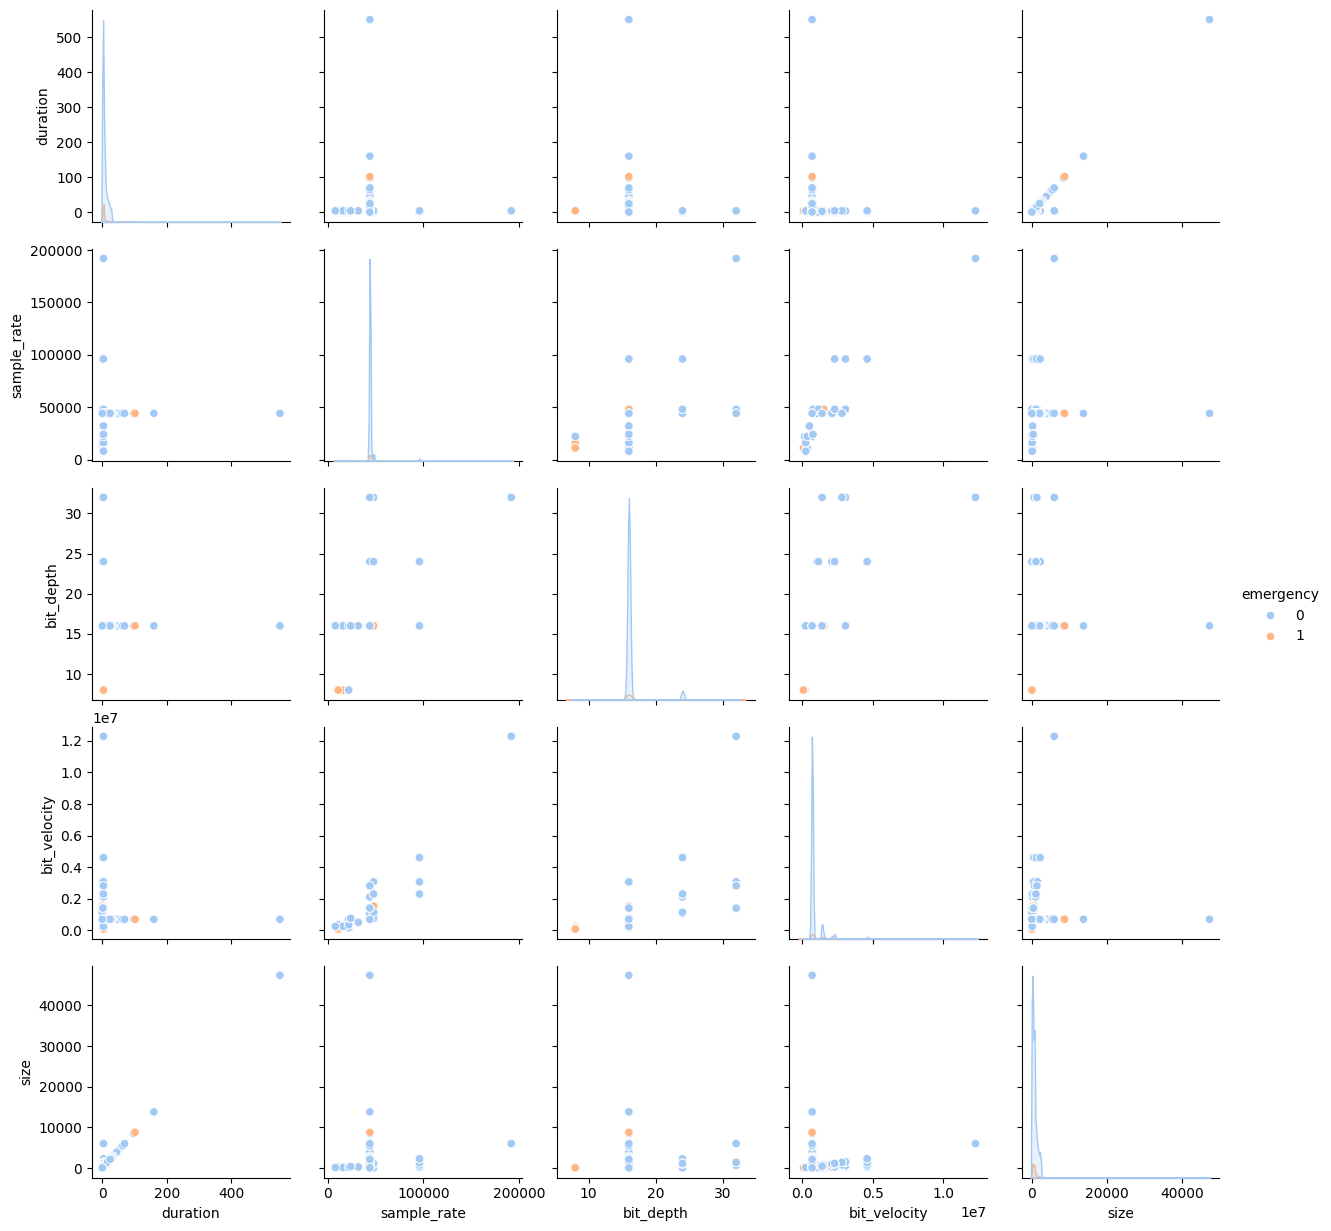

In [49]:
sns.pairplot(
    eda[numeric_cols + ["emergency"]],
    hue="emergency",
    palette="pastel"
)
plt.show()

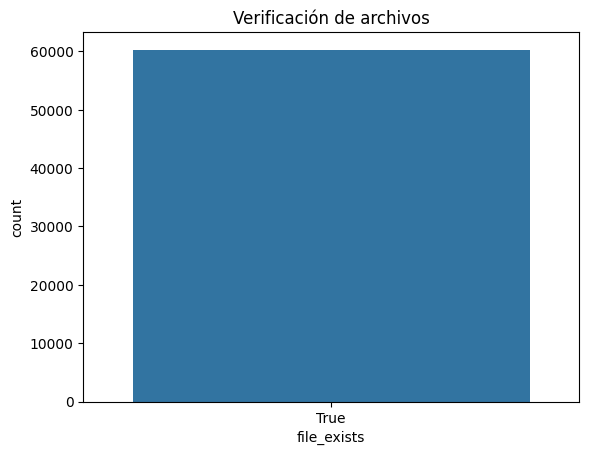

In [50]:
sns.countplot(data=eda, x="file_exists")
plt.title("Verificación de archivos")
plt.show()

- Integridad del dataset verificada.
- Archivos válidos para entrenamiento.

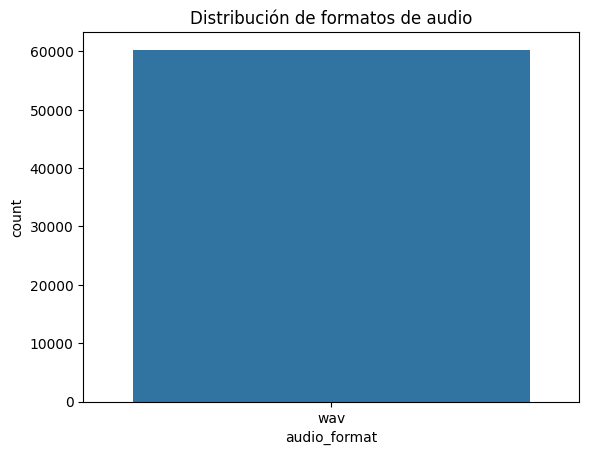

In [51]:
sns.countplot(data=eda, x="audio_format")
plt.title("Distribución de formatos de audio")
plt.show()

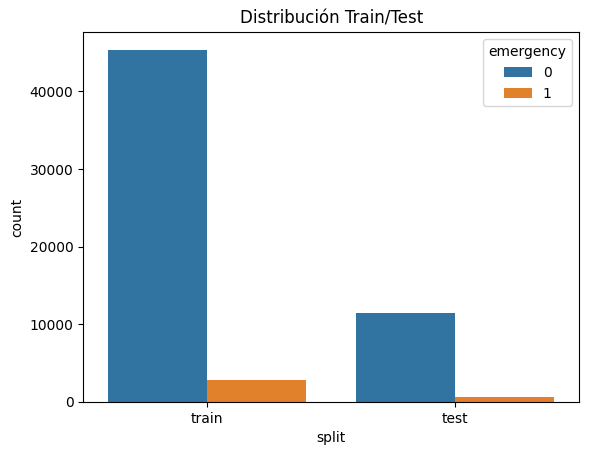

In [52]:
sns.countplot(data=eda, x="split", hue="emergency")
plt.title("Distribución Train/Test")
plt.show()

- División adecuada para validación.
- Mantiene eventos críticos en ambos conjuntos.

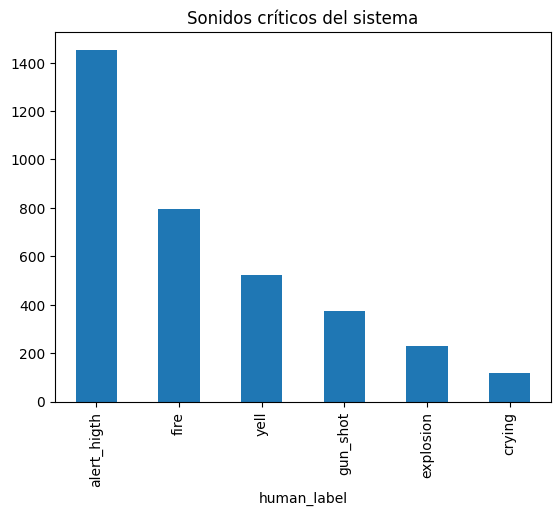

In [53]:
top_emergency = eda[
    eda["emergency"] == 1
]["human_label"].value_counts().head(15)

top_emergency.plot(kind="bar")
plt.title("Sonidos críticos del sistema")
plt.show()

El análisis exploratorio se realizó sobre human_label para interpretar el comportamiento acústico desde una perspectiva centrada en el usuario final, permitiendo identificar qué sonidos representan riesgos reales para personas con discapacidad auditiva.

hiak